<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/main/Advertising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Advertising (1).csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


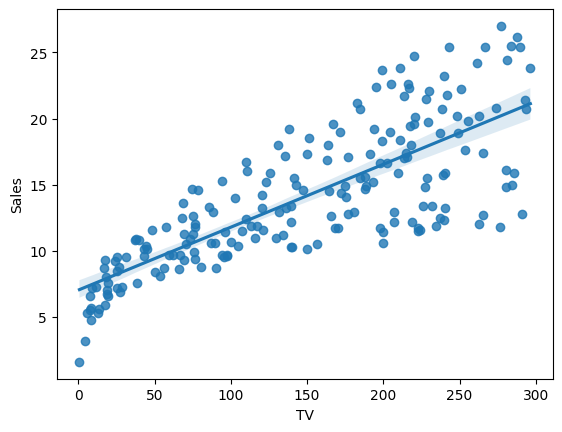

In [ ]:
sns.regplot(x="TV", y="Sales", data=df)
plt.show()

In [ ]:
df = df.drop(columns="Unnamed: 0")

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data = pd.DataFrame(scaled_data, columns=df.columns)
print(scaled_data)

           TV     Radio  Newspaper     Sales
0    0.969852  0.981522   1.778945  1.552053
1   -1.197376  1.082808   0.669579 -0.696046
2   -1.516155  1.528463   1.783549 -0.907406
3    0.052050  1.217855   1.286405  0.860330
4    0.394182 -0.841614   1.281802 -0.215683
..        ...       ...        ...       ...
195 -1.270941 -1.321031  -0.771217 -1.234053
196 -0.617035 -1.240003  -1.033598 -0.830548
197  0.349810 -0.942899  -1.111852 -0.234898
198  1.594565  1.265121   1.640850  2.205347
199  0.993206 -0.990165  -1.005979 -0.119610

[200 rows x 4 columns]


In [ ]:
X = df.drop(columns="Sales")
y = df["Sales"]
print(X)
print(y)


        TV  Radio  Newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
..     ...    ...        ...
195   38.2    3.7       13.8
196   94.2    4.9        8.1
197  177.0    9.3        6.4
198  283.6   42.0       66.2
199  232.1    8.6        8.7

[200 rows x 3 columns]
0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape
y_train.shape

lr_model =



(160,)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)



LinearRegression()

In [ ]:
lr_model.score(X_train, y_train)


0.8957008271017817

In [ ]:
y_pred = lr_model.predict(X_test)
print(y_pred)

comparison = pd.DataFrame({
    'Actual': y_test[:5].round(2),
    "Predicted": y_pred[:5].round(2),
    "Difference" : (y_pred - y_test)[:5].round(2)
})
print(comparison)

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967  9.04831992  6.65328312
 14.34554487  8.90349333  9.68959028 12.16494386  8.73628397 16.26507258
 10.27759582 18.83109103 19.56036653 13.25103464 12.33620695 21.30695132
  7.82740305  5.80957448 20.75753231 11.98138077  9.18349576  8.5066991
 12.46646769 10.00337695 21.3876709  12.24966368 18.26661538 20.13766267
 14.05514005 20.85411186 11.0174441   4.56899622]
     Actual  Predicted  Difference
95     16.9      16.41       -0.49
15     22.4      20.89       -1.51
30     21.4      21.55        0.15
158     7.3      10.61        3.31
128    24.7      22.11       -2.59


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 3.174097353976104
R-squared: 0.899438024100912
